# Customer Behavior Analytics & Churn Prediction Dashboard
**Task ID:** ML-INT-1 | **Domain:** Machine Learning 

---

## 1. Imports & Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, roc_curve)
import warnings
warnings.filterwarnings('ignore')

import joblib
import os

os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

sns.set_theme(style='whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Analysis Module

In [ ]:

df = pd.read_csv(r'F:\Internship\Teyzixcore\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("=== Summary Statistics ===")
display(df.describe())

print("\n=== Data Types ===")
print(df.dtypes)



=== Summary Statistics ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
# Handle missing values
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Handle outliers using IQR on numeric columns
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

print("After cleaning shape:", df.shape)

After cleaning shape: (5901, 21)


## 3. Feature Engineering

In [7]:
# ── Encode categorical columns ──
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    if col != 'Churn':          # keep target readable for now
        df[col] = le.fit_transform(df[col])

# ── Encode target ──
if df['Churn'].dtype == object:
    df['Churn'] = le.fit_transform(df['Churn'])

# ── Behavioral / trend features ──
# (These will only be created if the source columns exist)

if 'MonthlyCharges' in df.columns and 'TotalCharges' in df.columns:
    df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

if 'tenure' in df.columns:
    df['TenureGroup'] = pd.cut(df['tenure'],
                                bins=[0, 12, 24, 48, 72, 9999],
                                labels=[1, 2, 3, 4, 5]).astype('Int64')

if 'SeniorCitizen' in df.columns and 'tenure' in df.columns:
    df['SeniorTenureInteraction'] = df['SeniorCitizen'] * df['tenure']

print("Feature engineering done. New shape:", df.shape)
df.head()

Feature engineering done. New shape: (5901, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup,SeniorTenureInteraction
0,4490,0,0,1,0,1,0,1,0,0,...,0,0,1,2,29.85,2137,0,1068.500000,1,0
1,3306,1,0,0,0,34,1,0,0,2,...,0,1,0,3,56.95,1270,0,36.285714,3,0
2,2155,1,0,0,0,2,1,0,0,2,...,0,0,1,3,53.85,141,1,47.000000,1,0
3,4631,1,0,0,0,45,0,1,0,2,...,0,1,0,0,42.30,1212,0,26.347826,3,0
4,5445,0,0,0,0,2,1,0,1,0,...,0,0,1,2,70.70,814,1,271.333333,1,0


## 4. Data Visualizations

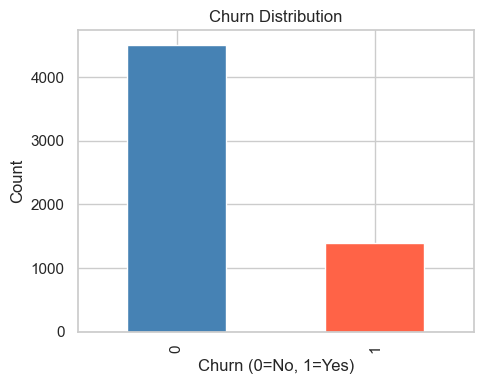

In [31]:
# ── Churn Distribution ──
fig, ax = plt.subplots(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'], ax=ax)
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn (0=No, 1=Yes)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
fig.savefig(
        "figures/churn_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.close(fig)

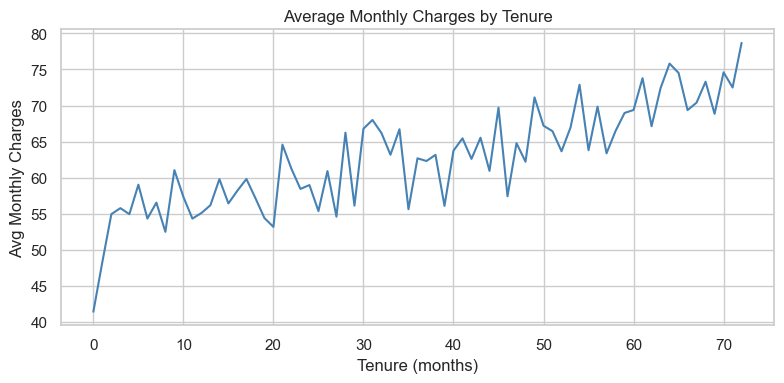

In [32]:
# ── Revenue Trend (MonthlyCharges by tenure) ──
if 'MonthlyCharges' in df.columns and 'tenure' in df.columns:
    trend = df.groupby('tenure')['MonthlyCharges'].mean()
    fig, ax = plt.subplots(figsize=(8, 4))
    trend.plot(ax=ax, color='steelblue')
    ax.set_title('Average Monthly Charges by Tenure')
    ax.set_xlabel('Tenure (months)')
    ax.set_ylabel('Avg Monthly Charges')
    plt.tight_layout()
    plt.show()
    fig.savefig(
        "figures/revenue_trend.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

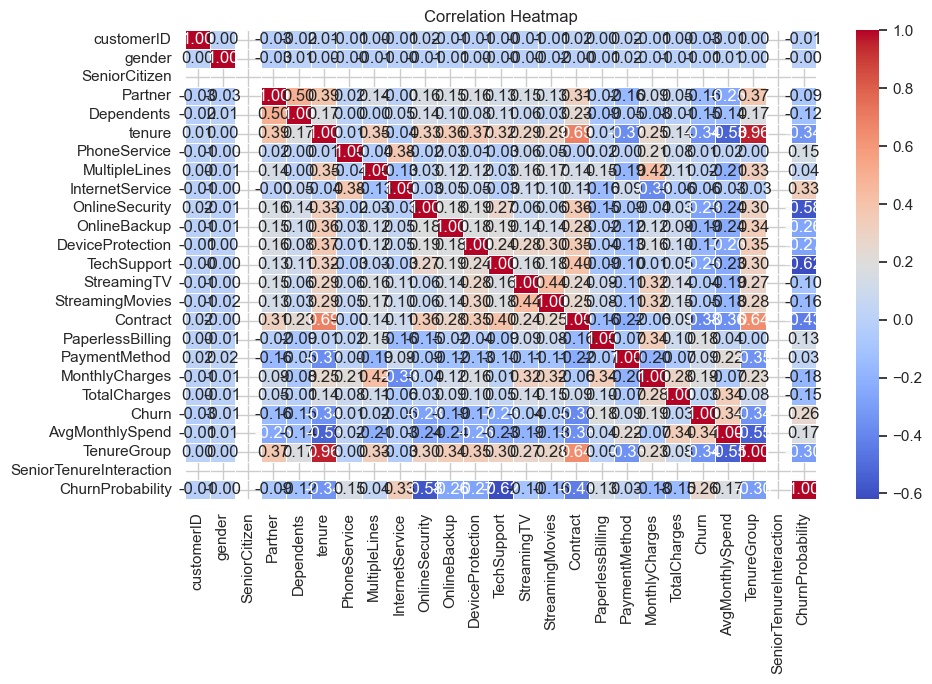

In [33]:
# ── Correlation Heatmap ──
fig, ax = plt.subplots(figsize=(10, 7))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()
fig.savefig(
        "figures/correlation_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.close(fig)

## 5. Customer Segmentation

CustomerSegment
High Value      2009
Low Value       1947
Medium Value    1945
Name: count, dtype: int64


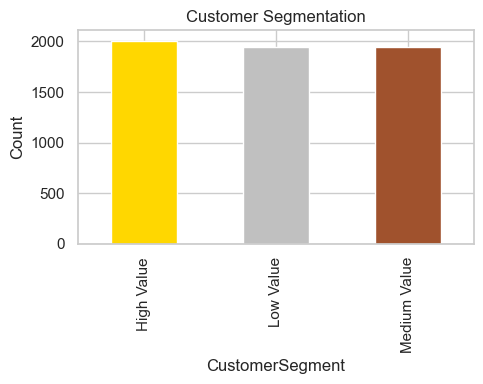

In [34]:
# Segment customers into High / Medium / Low value
# Based on MonthlyCharges (or TotalCharges if available)
charge_col = 'MonthlyCharges' if 'MonthlyCharges' in df.columns else df.select_dtypes('number').columns[0]

q33 = df[charge_col].quantile(0.33)
q66 = df[charge_col].quantile(0.66)

def segment(val):
    if val >= q66:
        return 'High Value'
    elif val >= q33:
        return 'Medium Value'
    else:
        return 'Low Value'

df['CustomerSegment'] = df[charge_col].apply(segment)

print(df['CustomerSegment'].value_counts())

# Segmentation chart
fig, ax = plt.subplots(figsize=(5, 4))
df['CustomerSegment'].value_counts().plot(kind='bar',
    color=['gold','silver','sienna'], ax=ax)
ax.set_title('Customer Segmentation')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
fig.savefig(
        "figures/customer_segmentation.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.close(fig)

## 6. Machine Learning Models

In [12]:
# ── Prepare X, y ──
drop_cols = ['Churn', 'CustomerSegment', 'customerID'] if 'customerID' in df.columns else ['Churn', 'CustomerSegment']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train size:", X_train.shape, "  Test size:", X_test.shape)

Train size: (4720, 22)   Test size: (1181, 22)


In [13]:
# ── Model 1: Logistic Regression ──
X_train_sc = np.nan_to_num(X_train_sc)
X_test_sc  = np.nan_to_num(X_test_sc)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression ===
Accuracy : 0.8357
Precision: 0.7033
Recall   : 0.5269
F1 Score : 0.6025
ROC-AUC  : 0.8517


In [14]:
# ── Model 2: Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest ===
Accuracy : 0.8180
Precision: 0.6684
Recall   : 0.4552
F1 Score : 0.5416
ROC-AUC  : 0.8247


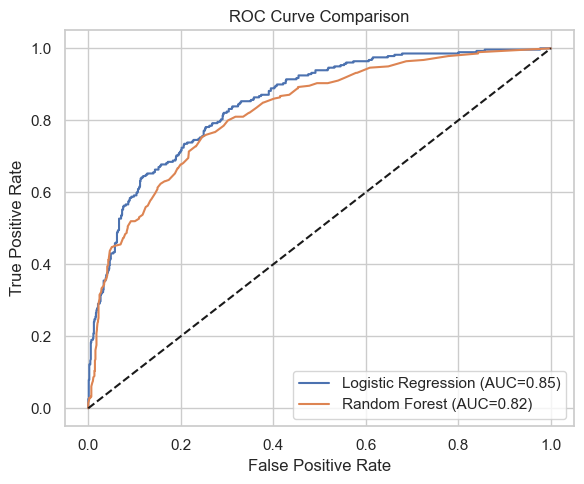

In [35]:
# ── ROC Curve Comparison ──
fig, ax = plt.subplots(figsize=(6, 5))

for name, y_prob in [('Logistic Regression', y_prob_lr), ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig(
        "figures/roc_curve_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.close(fig)

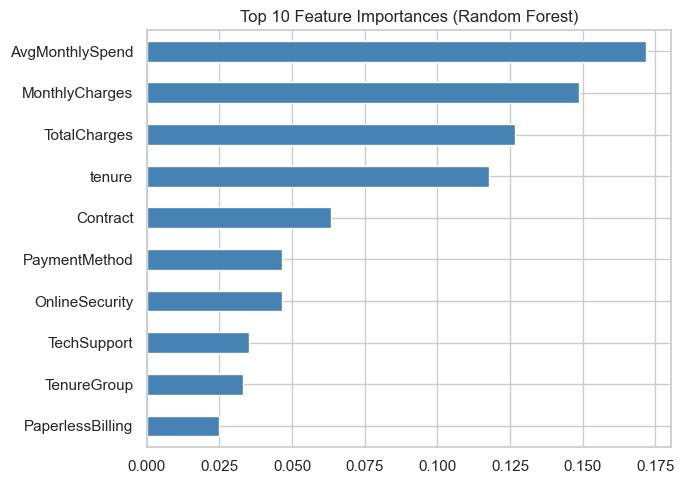

In [36]:
# ── Feature Importance (Random Forest) ──
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

fig, ax = plt.subplots(figsize=(7, 5))
top_features.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

fig.savefig(
        "figures/feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.close(fig)

## 7. Basic Churn Prediction System

In [17]:
# Assign churn probability and risk category to all customers
df['ChurnProbability'] = rf.predict_proba(
    scaler.transform(X) if hasattr(scaler, 'mean_') else X
)[:, 1]

def risk_category(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['RiskCategory'] = df['ChurnProbability'].apply(risk_category)

print(df['RiskCategory'].value_counts())
display(df[['ChurnProbability', 'RiskCategory']].head(10))

RiskCategory
Medium Risk    3950
Low Risk       1949
High Risk         2
Name: count, dtype: int64


,ChurnProbability,RiskCategory
0,0.44,Medium Risk
1,0.37,Low Risk
2,0.47,Medium Risk
3,0.30,Low Risk
4,0.53,Medium Risk
5,0.55,Medium Risk
6,0.54,Medium Risk
7,0.35,Low Risk
8,0.49,Medium Risk
9,0.37,Low Risk


## 8. Business Insights Report

In [18]:
# ── Top churn reasons (features most correlated with churn) ──
churn_corr = df.select_dtypes(include='number').corr()['Churn'].drop('Churn').abs().sort_values(ascending=False)
print("=== Top Features Correlated with Churn ===")
print(churn_corr.head(5))

# ── High-risk customer traits ──
high_risk = df[df['RiskCategory'] == 'High Risk']
print("\n=== High-Risk Customer Profile (mean values) ===")
display(high_risk.select_dtypes(include='number').mean().to_frame('High Risk Avg'))

=== Top Features Correlated with Churn ===
Contract           0.383615
tenure             0.344384
TenureGroup        0.344269
AvgMonthlySpend    0.336374
OnlineSecurity     0.280446
Name: Churn, dtype: float64

=== High-Risk Customer Profile (mean values) ===


,High Risk Avg
customerID,2616.5
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,33.0
PhoneService,1.0
MultipleLines,2.0
InternetService,1.0
OnlineSecurity,0.0


In [19]:
# ── Revenue impact estimation ──
if 'MonthlyCharges' in df.columns:
    revenue_at_risk = df[df['RiskCategory'] == 'High Risk']['MonthlyCharges'].sum()
    total_revenue   = df['MonthlyCharges'].sum()
    pct = (revenue_at_risk / total_revenue) * 100

    print(f"Monthly Revenue at Risk (High Risk customers): ${revenue_at_risk:,.2f}")
    print(f"Total Monthly Revenue                        : ${total_revenue:,.2f}")
    print(f"Percentage at Risk                           : {pct:.1f}%")

Monthly Revenue at Risk (High Risk customers): $169.40
Total Monthly Revenue                        : $364,961.75
Percentage at Risk                           : 0.0%


## 9. Save Model

In [20]:
## Save Models
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(lr, 'models/logistic_regression.pkl')
joblib.dump(rf, 'models/random_forest.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(list(X.columns), 'models/feature_cols.pkl')  # Save feature columns for future reference

print("Models saved:")
print("  models/logistic_regression.pkl")
print("  models/random_forest.pkl")
print("  models/scaler.pkl")

Models saved:
  models/logistic_regression.pkl
  models/random_forest.pkl
  models/scaler.pkl
